# Running a pipeline and understanding the cache

This example walks through a two-loader pipeline — `ElevationLoader` →
`SlopeLoader` — from first run to cache hit to invalidation. The goal is to
make the hash chain concrete: what goes into each hash, what file lands where,
and exactly what triggers a recompute.

## Setup

In a real project you configure the cache and registry paths once and define a
`SPEC` that is fixed for the whole project. Changing `SPEC` invalidates every
cached output because the spec is folded into the state hash.

```python
import pygeodata as pgd
from pygeodata.types import SpatialSpec
from pyproj import CRS

pgd.get_config().update(
    path_cache='data_processed',
    path_registry='.source',
)

SPEC = SpatialSpec(
    crs=CRS.from_epsg(3035),
    transform=pgd.SpatialSpec.from_raster_file('reference.tif').transform,
    shape=(4400, 6600),
)
```

## Loader definitions

Loaders must live in importable modules — pygeodata reads their source code
via `inspect.getsource` for cache invalidation. Defining them inline in a
script or notebook would produce unstable source hashes.

`SlopeLoader` holds a reference to `ElevationLoader` as a constructor
parameter. This is the *data-as-parameters* pattern: the dependency is
explicit, typed, and part of the hash.

In [1]:
# loaders/dem.py — importable module
import sys, os

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from loaders.dem import ElevationLoader, SlopeLoader

print(ElevationLoader())
print(SlopeLoader())

ElevationLoader(src='data/srtm_30m.tif')
SlopeLoader(elevation=ElevationLoader(src='data/srtm_30m.tif'))


The loader source for reference:

```python
# loaders/dem.py
from dataclasses import dataclass

import numpy as np
from pygeodata.api import load
from pygeodata.data import Data
from pygeodata.drivers.rioxarray import RioXArrayDriver
from pygeodata.processors.reprojection import Reprojector
from pygeodata.types import SpatialSpec
from rasterio.enums import Resampling


@dataclass
class ElevationLoader(Data):
    """Reproject the source DEM to the target spec."""

    src: str = 'data/srtm_30m.tif'

    @property
    def processor(self):
        return Reprojector(src_path=self.src, resampling=Resampling.bilinear, dst_dtype=np.float32)


@dataclass
class SlopeLoader(Data):
    """Terrain slope derived from ElevationLoader, in degrees."""

    elevation: ElevationLoader = None

    ext = 'tif'
    driver = RioXArrayDriver()

    def __post_init__(self):
        if self.elevation is None:
            self.elevation = ElevationLoader()

    def _process(self, spec: SpatialSpec) -> None:
        import xrspatial
        dem = load(self.elevation, spec)
        slope = xrspatial.slope(dem)
        slope.rio.to_raster(self.get_processed_path(spec))
```

## First run

```python
pgd.process(SlopeLoader(), SPEC)
```

What happens:

1. `SlopeLoader.process(SPEC)` calls `is_processed(SPEC)`. The hash file
   does not exist yet, so this returns `False`.
2. `SlopeLoader._process(SPEC)` calls `load(self.elevation, SPEC)`.
   `load` calls `ElevationLoader.process(SPEC)` first — same cache check,
   same miss, so the DEM reprojection runs.
3. `ElevationLoader.write_cache_metadata(SPEC)` writes its hash file.
4. Back in `SlopeLoader._process`, the slope raster is computed and written.
5. `SlopeLoader.write_cache_metadata(SPEC)` writes its hash file.
6. Both classes call `update_registry()`, which writes their source code
   and dependency tree snapshot to `.source/`.

## What lands on disk

```
data_processed/
└── <slope_state_hash>/            ← SHA-256 of (instance_hash, spec)
    ├── slope_loader.tif           ← the output raster
    ├── .slope_loader.hash.json    ← written by write_cache_metadata()
    ├── .slope_loader.params.json  ← serialised constructor parameters
    └── .slope_loader.spec.json    ← the SpatialSpec used

.source/
├── code/
│   ├── <elevation_source_hash>/
│   │   ├── source.py              ← ElevationLoader class body (verbatim)
│   │   └── source.json            ← {class_name, source_hash, registered_at, …}
│   └── <slope_source_hash>/
│       ├── source.py
│       └── source.json
└── snapshots/
    └── <slope_dep_tree_hash>/
        ├── tree.json              ← {nodes, tree} dependency topology
        └── graph.pdf              ← rendered class dependency graph
```

Each directory under `data_processed/` is named by the **state hash** —
a SHA-256 that binds together the instance hash and the spec. Two runs on
different specs for the same loader land in different directories and never
interfere.

## The `.hash.json` file

After processing, each output directory contains a sidecar
`.slope_loader.hash.json`:

```json
{
    "format_version": 1,
    "class_name": "SlopeLoader",
    "object_type": "Data",
    "source_hash": "a3f8…",
    "dependency_tree_hash": "7c11…",
    "instance_hash": "b902…",
    "state_hash": "d45e…",
    "co_outputs": []
}
```

The fields and what changes them:

**`source_hash`** — SHA-256 of the AST of `SlopeLoader` alone — its own class
body, nothing else. Whitespace and docstring changes that do not affect the AST
do not change this hash.

**`dependency_tree_hash`** — SHA-256 of the entire dependency tree rooted at
`SlopeLoader`. This includes the source hashes of `ElevationLoader` and every
other transitively reachable class. Changing `ElevationLoader`'s code changes
this hash even if `SlopeLoader` is untouched.

**`instance_hash`** — SHA-256 of `{dependency_tree_hash, params}`. Two
`SlopeLoader` instances with different `elevation` values have different
instance hashes. Spec-independent.

**`state_hash`** — SHA-256 of `{instance_hash, spec}`. This is the directory
name under `data_processed/`. It is unique per (loader instance, spec) pair.

**`co_outputs`** — State hashes of sibling artifacts produced in the same
`_process` call (the co-output pattern). Empty here; see the custom processing
tutorial for an example.

## Second run — cache hit

```python
pgd.process(SlopeLoader(), SPEC)   # no-op
```

`is_processed(SPEC)` reads `.slope_loader.hash.json`, computes the live
state hash, and finds them equal. `_process` is never called.

## The dependency graph

The class-level graph is built by static AST analysis: pygeodata walks the
class body of each registered `TrackedObject`, finds references to other
registered classes, and records them as call edges. No data files are needed
to generate it.

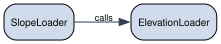

In [2]:
import os, tempfile
from pygeodata.graphs import plot_class_dependency_graph
from IPython.display import SVG, display

graph_data = SlopeLoader.get_dependency_graph()

with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, 'graph_slope.svg')
    plot_class_dependency_graph(
        cls_name='SlopeLoader',
        graph_data=graph_data,
        path=path,
    )
    display(SVG(path))

Arrows point from dependent to dependency (`SlopeLoader` → `ElevationLoader`).
The graph is stored at `.source/snapshots/<dep_tree_hash>/graph.pdf` and
written once per unique dependency tree hash. Viewing it in the registry
browser's Code tab shows which version of the dependency tree was active when
any particular output was produced.

## Cache invalidation

### Scenario 1: change a parameter

Change the default source path in `ElevationLoader`:

```python
@dataclass
class ElevationLoader(Data):
    src: str = 'data/copernicus_dem_30m.tif'   # was: srtm_30m.tif
    ...
```

The class body changed. On the next `process(SlopeLoader(), SPEC)` call:

1. `calculate_cls_source_hash(ElevationLoader)` produces a new hash.
2. `SlopeLoader.get_dependency_tree_hash()` recomputes — it includes
   `ElevationLoader`'s source hash — and also changes.
3. `SlopeLoader.get_instance_hash()` changes (depends on dep_tree_hash).
4. `SlopeLoader.get_state_hash(SPEC)` changes (depends on instance_hash).
5. `is_processed(SPEC)` reads the old state hash from disk, compares it to
   the new live hash, and returns `False`.
6. Both loaders recompute.

The old output remains on disk under its old state hash directory. It will be
cleaned up by `clean_cache()`.

### Scenario 2: change a constructor argument

```python
# default: SlopeLoader(elevation=ElevationLoader(src='data/srtm_30m.tif'))
pgd.process(SlopeLoader(elevation=ElevationLoader(src='data/eu_dem.tif')), SPEC)
```

The `params` dict of the outer `SlopeLoader` instance changes because it
contains a reference to a different `ElevationLoader` instance (whose own
instance hash is different). The state hash changes, a new directory is
created, and the old one is untouched. You now have two cached versions of
the slope raster simultaneously — one per elevation source.

### Scenario 3: edit the `SlopeLoader` class body

Add a `smooth` parameter:

```python
@dataclass
class SlopeLoader(Data):
    elevation: ElevationLoader = None
    smooth: int = 0              # new parameter

    def _process(self, spec: SpatialSpec) -> None:
        import xrspatial
        dem = load(self.elevation, spec)
        slope = xrspatial.slope(dem)
        if self.smooth:
            slope = slope.rolling(x=self.smooth, y=self.smooth,
                                  center=True).mean()
        slope.rio.to_raster(self.get_processed_path(spec))
```

`SlopeLoader`'s own `source_hash` changes. Its `dependency_tree_hash`
changes. Its `instance_hash` changes (because `smooth=0` is now in the
params dict). The state hash changes. Cache miss, recompute.

Note that `ElevationLoader` is unaffected — its own cache entry is still
valid. Only `SlopeLoader`'s output is recomputed.